# [실습3] 선형 회귀 모델을 활용한 배터리 양극재 결정구조 분류 (정답)
---

## 실습 목표

- 선형 회귀 모델의 원리를 이해하고 코드를 작성합니다.
- 피처 엔지니어링이 선형 회귀 모델에 실질적으로 미치는 영향을 파악합니다.
- 실습 데이터를 이용해 선형 회귀 모델을 학습해보고, 분류 문제에 적합한 로지스틱 회귀 모델을 적용합니다.

---

## 실습 목차

1. **단일 변수 선형 회귀 모델** 

2. **다변수 선형 회귀 모델** 

3. **다변수 다중 출력 선형 회귀 모델**

4. **피처 엔지니어링의 중요성** 

5. **실습 데이터 불러오기 및 선형 회귀 모델 적용** 

6. **로지스틱 회귀 모델** 
---

## 실습 개요

이번 실습에서는 선형 회귀 모델을 구현하고 실습 데이터에 어떻게 적용될 수 있는지 확인합니다.

---

## 1. 단일 변수 선형 회귀 모델
---
선형 회귀 모델에 대한 일반적인 이해를 하기 위해, 랜덤으로 생성한 임시 데이터를 사용하겠습니다.

In [100]:
## 라이브러리 불러오기
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 

---
### 1.1 데이터 생성
독립변수가 1개이고 종속변수도 1개인 데이터를 생성합니다.

In [101]:
random_seed = 42
np.random.seed(random_seed)

data_size = 500
X = 2.5 * np.random.normal(size=data_size) + 1.5   
res = 0.2 * np.random.normal(size=data_size)
y = 0.3 * X + res

df = pd.DataFrame(
    {'X': X,
     'y': y}
)

X = df.iloc[:, :-1].values
y = df.iloc[:, 1].values

print(X.shape)
print(y.shape)

(500, 1)
(500,)


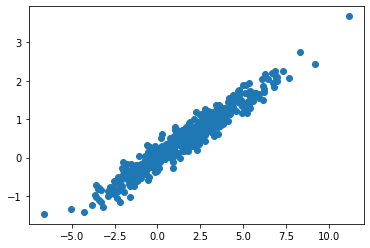

In [102]:
plt.scatter(X, y)
plt.show()

---
### 1.2 학습 & 테스트 데이터 구분
7:3 의 비율로 학습 데이터와 테스트 데이터를 구분합니다.

In [103]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X, y, test_size=0.3, random_state=random_seed)

print(X_train.shape)
print(X_test.shape)
print(Y_train.shape)
print(Y_test.shape)

(350, 1)
(150, 1)
(350,)
(150,)


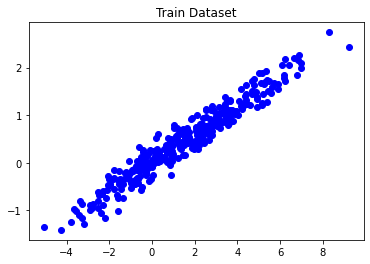

In [104]:
plt.scatter(X_train, Y_train, color='blue')
plt.title("Train Dataset")
plt.show()

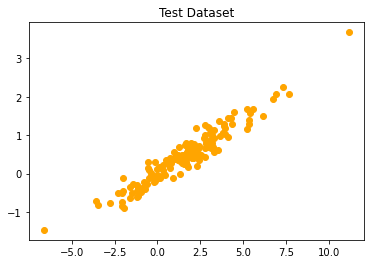

In [105]:
plt.scatter(X_test, Y_test, color='orange')
plt.title("Test Dataset")
plt.show()

---
### 1.3 선형 회귀 모델 학습
sklearn 라이브러리를 이용해 선형 회귀 모델을 학습합니다. 학습 데이터만 사용해 학습을 진행합니다.

In [106]:
from sklearn.linear_model import LinearRegression
regressor = LinearRegression()
regressor.fit(X_train, Y_train)

LinearRegression()

단변수를 이용한 추정이기 때문에, 학습 결과를 간단한 선형식으로 나타낼 수 있습니다. 이를 나타내면 아래와 같습니다.

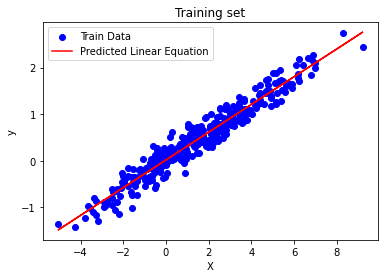

In [107]:
plt.scatter(X_train, Y_train, color='blue', label='Train Data')
plt.plot(X_train, regressor.predict(X_train), color='red', label='Predicted Linear Equation')
plt.title('Training set')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.show()

---
### 1.4 테스트 데이터 예측
학습한 모델을 이용해 테스트 데이터를 예측합니다. 

In [108]:
Y_pred = regressor.predict(X_test)

테스트 데이터에 대한 예측 결과를 시각화하면 아래와 같습니다. 여기서 GT란 Ground Truth, 즉 정답 데이터라는 뜻입니다.

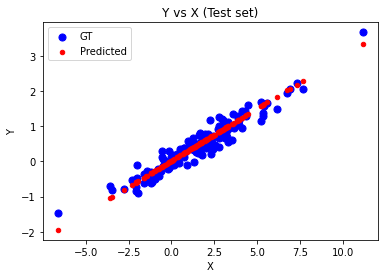

In [109]:
plt.scatter(X_test, Y_test, color = 'blue', s=50, label='GT')
plt.scatter(X_test, Y_pred, color = 'red', s=20, label='Predicted')
plt.title('Y vs X (Test set)')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.show()

---
### 1.5 모델 평가 지표
회귀 모델의 성능을 평가하는 방법은 여러가지가 있습니다. 우선 MAE부터 알아보겠습니다.

MAE는 Mean Absolute Error의 줄임말로, 에러들의 절댓값에 평균을 취한 값입니다.

평균적인 에러의 크기를 가늠하는데 사용할 수 있습니다.

In [110]:
def calculate_mae(y_true, y_pred):
    mae = np.mean(np.abs(y_true - y_pred))
    return mae

In [111]:
mae = calculate_mae(Y_test, Y_pred)
print(mae)

0.1670413018870722


MSE (Mean Squared Error)는 실제 값과 예측 값의 차이를 제곱하여 평균을 낸 값입니다.

MAE와 다르게 에러가 제곱된다는 것이 특징입니다. 따라서 에러가 1보다 클 경우, 즉 큰 에러가 발생할 경우 강조된다는 특성이 있습니다.

In [112]:
def calculate_mse(y_true, y_pred):
    mse = np.mean((y_true - y_pred)**2)
    return mse

In [113]:
mse = calculate_mse(Y_test, Y_pred)
print(mse)

0.04373041503359388


RMSE (Root Mean Squared Error)는 MSE의 제곱근입니다. MSE와 마찬가지로, 실제 값과 예측 값의 차이를 제곱하여 평균을 낸 후 그 결과의 제곱근을 구합니다.

RMSE는 제곱되었던 에러의 제곱근을 구하면서, 에러의 단위가 다시 원래대로 돌아온다는 특성이 있습니다. 

따라서, 평균적으로 모델이 데이터셋에 대해서 얼마나 틀리고 있는지 직관적으로 관찰할 수 있다는 장점이 있습니다.

In [114]:
def calculate_rmse(y_true, y_pred):
    mse = np.mean((y_true - y_pred)**2)
    rmse = np.sqrt(mse)
    return rmse

In [115]:
rmse = calculate_rmse(Y_test, Y_pred)
print(rmse)

0.20911818436853807


R2 Score는 실제 값과 예측 값 사이의 상관 관계를 나타내는 지표입니다. 이는 1 - (SSR/SST) 로 계산됩니다, 여기서 SSR은 'Sum of Squares of Residuals'로 예측값과 실제값 간의 차이 제곱의 합이고, SST는 'Total Sum of Squares'로 실제값과 실제값의 평균 간의 차이 제곱의 합입니다

In [116]:
def calculate_r2(y_true, y_pred):
    ssr = np.sum((y_true - y_pred)**2)
    sst = np.sum((y_true - np.mean(y_true))**2)
    r2 = 1 - (ssr / sst)
    return r2

In [117]:
r2 = calculate_r2(Y_test, Y_pred)
print(r2)

0.9136556479287816


위의 모델 평가 지표들은 sklearn 라이브러리에서 함수로 제공하고 있습니다. 이를 불러와 사용해도 동일한 결과를 얻을 수 있습니다.

In [118]:
from sklearn import metrics
print('Mean Absolute Error:', metrics.mean_absolute_error(Y_test, Y_pred))  
print('Mean Squared Error:', metrics.mean_squared_error(Y_test, Y_pred))  
print('Root Mean Squared Error:', np.sqrt(metrics.mean_squared_error(Y_test, Y_pred)))
print('R2 Score:', metrics.r2_score(Y_test, Y_pred))

Mean Absolute Error: 0.1670413018870722
Mean Squared Error: 0.04373041503359388
Root Mean Squared Error: 0.20911818436853807
R2 Score: 0.9136556479287816


---
## 2. 다변수 선형 회귀 모델
---
### 2.1 다변수 데이터 생성
독립변수가 4개이고 종속변수가 1개인 데이터를 생성합니다.

X4 변수에 대해서는 일부로 종속변수와 관련이 없도록 설정해보겠습니다.

In [119]:
data_size = 1000

X1 = np.random.normal(size=data_size) * 10
X2 = np.random.normal(size=data_size) * 10
X3 = np.random.normal(size=data_size) * 10
X4 = np.random.normal(size=data_size) * 10

beta_1 = 3
beta_2 = 2
beta_3 = 4
beta_4 = 0

# X4와는 연관성이 없는 종속변수 Y를 생성한다
y = beta_1*X1 + beta_2*X2 + beta_3*X3 + beta_4*X4 + np.random.normal(size=data_size)

# Create a dataframe
df = pd.DataFrame({
    'X1': X1,
    'X2': X2,
    'X3': X3,
    'X4': X4,
    'y' : y
})

print(X1.shape, X2.shape, X3.shape, X4.shape)
print(y.shape)

(1000,) (1000,) (1000,) (1000,)
(1000,)


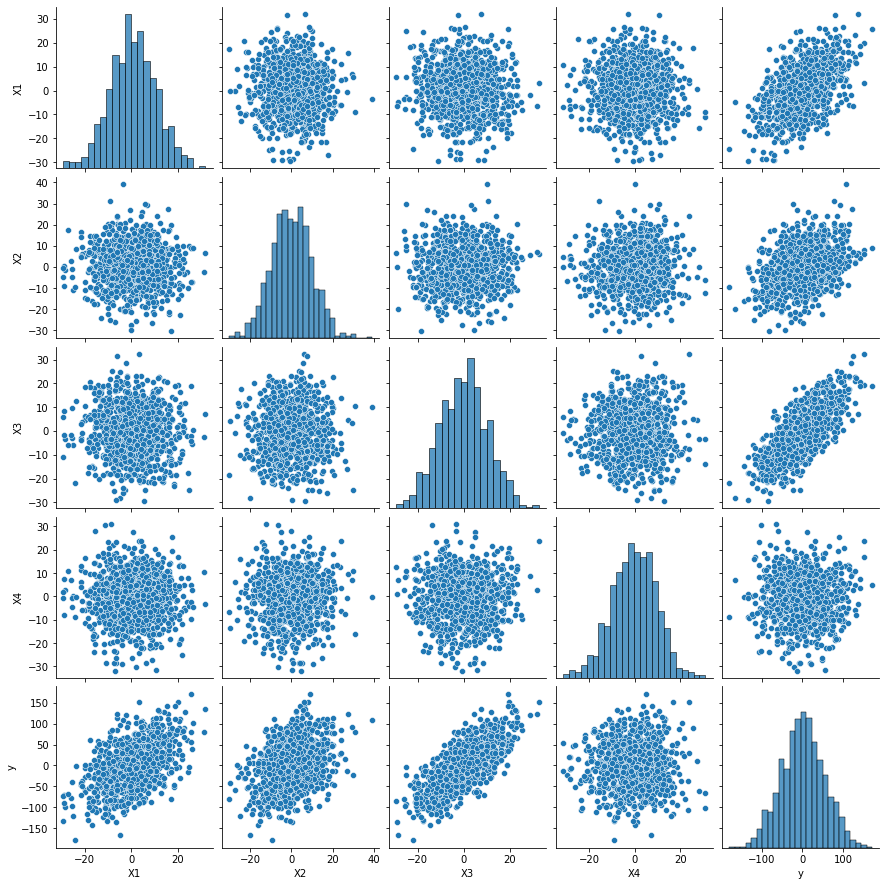

In [120]:
import seaborn as sns
sns.pairplot(df)
plt.show()

그래프를 관찰하면 X4 변수와 y는 상관관계가 없다는 것을 간접적으로 확인할 수 있습니다.

상관관계를 직접적으로 시각화하면 다음과 같습니다.

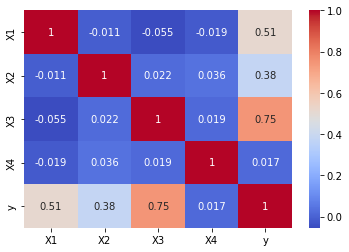

In [121]:
corr = df.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

상관계수 히트맵을 확인하면 X4가 Y와 상관 관계가 가장 낮은 것을 확인할 수 있습니다. 

따라서 이와 같은 변수는 모델을 학습하기 전 제거해주는 것이 바람직합니다.

이 변수를 제거하고 남은 3개의 변수로 다변수 회귀 분석을 해보겠습니다:

In [122]:
# Drop the least correlated variable
df = df.drop('X4', axis=1)

# Get new independent variables
X = df[['X1', 'X2', 'X3']]
display(df)

,X1,X2,X3,y
0,13.993554,-6.751783,-19.078076,-48.258964
1,9.246337,-1.445187,-8.603850,-10.020177
2,0.596304,-7.924199,-4.136055,-32.399352
3,-6.469368,-3.079615,18.876877,49.610082
4,6.982233,-18.936147,5.565531,6.069360
...,...,...,...,...
995,10.701502,0.774805,0.284576,34.963890
996,-0.265213,2.577525,-20.778118,-77.600412
997,-8.818747,-12.417606,-3.202978,-65.320767
998,-1.630670,3.341764,16.433782,67.994596


---
### 2.2 학습 & 테스트 데이터 구분
7:3 의 비율로 학습 데이터와 테스트 데이터를 구분합니다.

In [123]:
X_train, X_test, Y_train, Y_test = train_test_split(X, y, test_size=0.3, random_state=random_seed)

print(X_train.shape)
print(X_test.shape)
print(Y_train.shape)
print(Y_test.shape)

(700, 3)
(300, 3)
(700,)
(300,)


---
### 2.3 선형 회귀 모델 학습
sklearn 라이브러리를 이용해 선형 회귀 모델을 학습합니다. 학습 데이터만 사용해 학습을 진행합니다.

In [124]:

# 회귀 모델을 생성하고 학습합니다
model = LinearRegression()
model.fit(X_train, Y_train)


LinearRegression()

모델이 예측한 식을 다음과 같이 출력해볼 수 있습니다. 

선형 회귀 모델이기 때문에 각 변수의 선형적인 관계들로 종속변수 y가 묘사됩니다.

In [125]:
# 예측한 각 변수의 계수를 확인합니다.
print("예측 식: y = {:.3f} X1 + {:.3f} X2 + {:.3f} X3 ".format(model.coef_[0], model.coef_[1], model.coef_[2]))
print("실제 식: y = {:.3f} X1 + {:.3f} X2 + {:.3f} X3 ".format(beta_1, beta_2, beta_3))

예측 식: y = 3.003 X1 + 2.000 X2 + 4.004 X3 
실제 식: y = 3.000 X1 + 2.000 X2 + 4.000 X3 


---
### 2.4 테스트 데이터 예측
학습한 모델을 이용해 테스트 데이터를 예측합니다. 

In [126]:
# 학습한 모델을 이용해 테스트 데이터에 대해 예측을 합니다
Y_pred = model.predict(X_test)

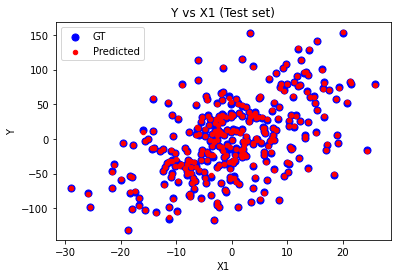

In [127]:
plt.scatter(X_test['X1'], Y_test, color = 'blue', s=50, label='GT')
plt.scatter(X_test['X1'], model.predict(X_test), color = 'red', s=20, label='Predicted')
plt.title('Y vs X1 (Test set)')
plt.xlabel('X1')
plt.ylabel('Y')
plt.legend()
plt.show()


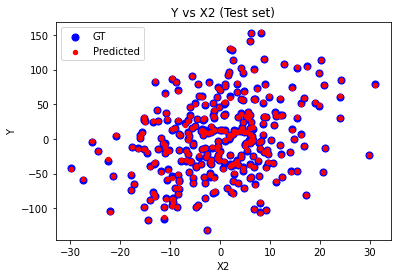

In [128]:
plt.scatter(X_test['X2'], Y_test, color = 'blue', s=50, label='GT')
plt.scatter(X_test['X2'], model.predict(X_test), color = 'red', s=20, label='Predicted')
plt.title('Y vs X2 (Test set)')
plt.xlabel('X2')
plt.ylabel('Y')
plt.legend()
plt.show()


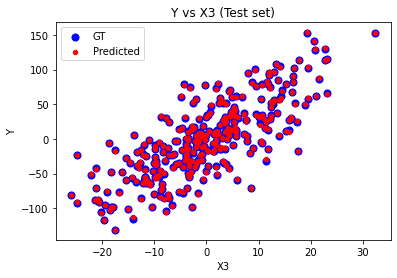

In [129]:
plt.scatter(X_test['X3'], Y_test, color = 'blue', s=50, label='GT')
plt.scatter(X_test['X3'], model.predict(X_test), color = 'red', s=20, label='Predicted')
plt.title('Y vs X3 (Test set)')
plt.xlabel('X3')
plt.ylabel('Y')
plt.legend()
plt.show()

세 가지 변수에 대해 매우 정확하게 테스트 데이터를 예측하는 것을 확인할 수 있습니다. 

이는 종속변수 y가 독립변수들과 거의 완벽한 선형 관계를 갖기 때문에 가능한 일입니다.

---
### 2.5 모델 평가 지표

In [130]:
print('Mean Absolute Error:', metrics.mean_absolute_error(Y_test, Y_pred))  
print('Mean Squared Error:', metrics.mean_squared_error(Y_test, Y_pred))  
print('Root Mean Squared Error:', np.sqrt(metrics.mean_squared_error(Y_test, Y_pred)))
print('R2 Score:', metrics.r2_score(Y_test, Y_pred))

Mean Absolute Error: 0.8040904991881316
Mean Squared Error: 1.0200461303050437
Root Mean Squared Error: 1.009973331482096
R2 Score: 0.9996599778025249


---
## 3. 다변수 다중 출력 선형 회귀 모델
---
### 3.1 다변수 다중 출력 데이터 생성
종속 변수가 2개 이상이면 다중 출력 회귀를 해야 합니다. 독립 변수가 3개, 종속 변수가 2개인 데이터를 생성합니다.

In [131]:
X1 = np.random.normal(size=data_size) * 10
X2 = np.random.normal(size=data_size) * 10
X3 = np.random.normal(size=data_size) * 10

beta_11 = 3
beta_12 = 2
beta_13 = 1
beta_21 = 2
beta_22 = 1
beta_23 = 3

# X4와는 연관성이 없는 종속변수 Y를 생성한다
y1 = beta_11*X1 + beta_12*X2 + beta_13*X3 + np.random.normal(size=data_size)
y2 = beta_21*X1 + beta_22*X2 + beta_23*X3 + np.random.normal(size=data_size)

df = pd.DataFrame({
    'X1': X1.flatten(),
    'X2': X2.flatten(),
    'X3': X3.flatten(),
    'y1': y1.flatten(),
    'y2': y2.flatten()
})


print(X1.shape, X2.shape, X3.shape, X4.shape)
print(y1.shape, y2.shape)

(1000,) (1000,) (1000,) (1000,)
(1000,) (1000,)


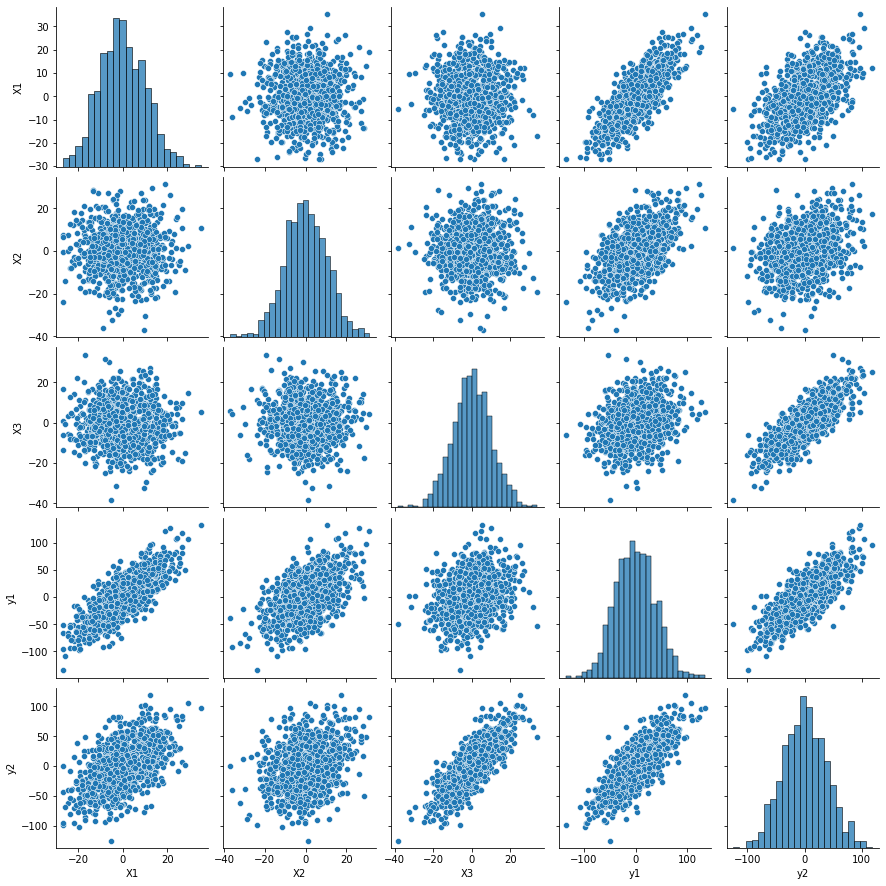

In [132]:
sns.pairplot(df)
plt.show()

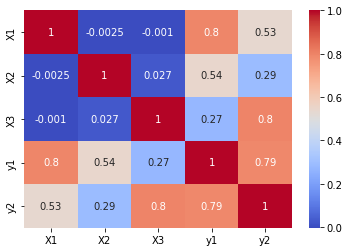

In [133]:
corr = df.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

---
### 3.2 학습 & 테스트 데이터 구분
7:3 의 비율로 학습 데이터와 테스트 데이터를 구분합니다.

In [134]:
X = df[['X1', 'X2', 'X3']]
y = df[['y1', 'y2']]
X_train, X_test, Y_train, Y_test = train_test_split(X, y, test_size=0.3, random_state=random_seed)

print(X_train.shape)
print(X_test.shape)
print(Y_train.shape)
print(Y_test.shape)

(700, 3)
(300, 3)
(700, 2)
(300, 2)


---
### 3.3 선형 회귀 모델 학습
sklearn 라이브러리를 이용해 선형 회귀 모델을 학습합니다. 학습 데이터만 사용해 학습을 진행합니다.

In [135]:

# 회귀 모델을 생성하고 학습합니다
model = LinearRegression()
model.fit(X_train, Y_train)


LinearRegression()

모델이 예측한 식을 다음과 같이 출력해볼 수 있습니다. 

선형 회귀 모델이기 때문에 각 변수의 선형적인 관계들로 종속변수 y가 묘사됩니다.

In [136]:
# 예측한 각 변수의 계수를 확인합니다.
print("예측 식: y1 = {:.3f} X1 + {:.3f} X2 + {:.3f} X3 ".format(model.coef_[0][0], model.coef_[0][1], model.coef_[0][2]))
print("실제 식: y1 = {:.3f} X1 + {:.3f} X2 + {:.3f} X3 ".format(beta_11, beta_12, beta_13))
print()
print("예측 식: y2 = {:.3f} X1 + {:.3f} X2 + {:.3f} X3 ".format(model.coef_[1][0], model.coef_[1][1], model.coef_[1][2]))
print("실제 식: y2 = {:.3f} X1 + {:.3f} X2 + {:.3f} X3 ".format(beta_21, beta_22, beta_23))

예측 식: y1 = 3.004 X1 + 1.996 X2 + 0.998 X3 
실제 식: y1 = 3.000 X1 + 2.000 X2 + 1.000 X3 

예측 식: y2 = 2.004 X1 + 0.997 X2 + 3.003 X3 
실제 식: y2 = 2.000 X1 + 1.000 X2 + 3.000 X3 


---
### 3.4 테스트 데이터 예측
학습한 모델을 이용해 테스트 데이터를 예측합니다. 

In [137]:
# 학습한 모델을 이용해 테스트 데이터에 대해 예측을 합니다
Y_pred = model.predict(X_test)

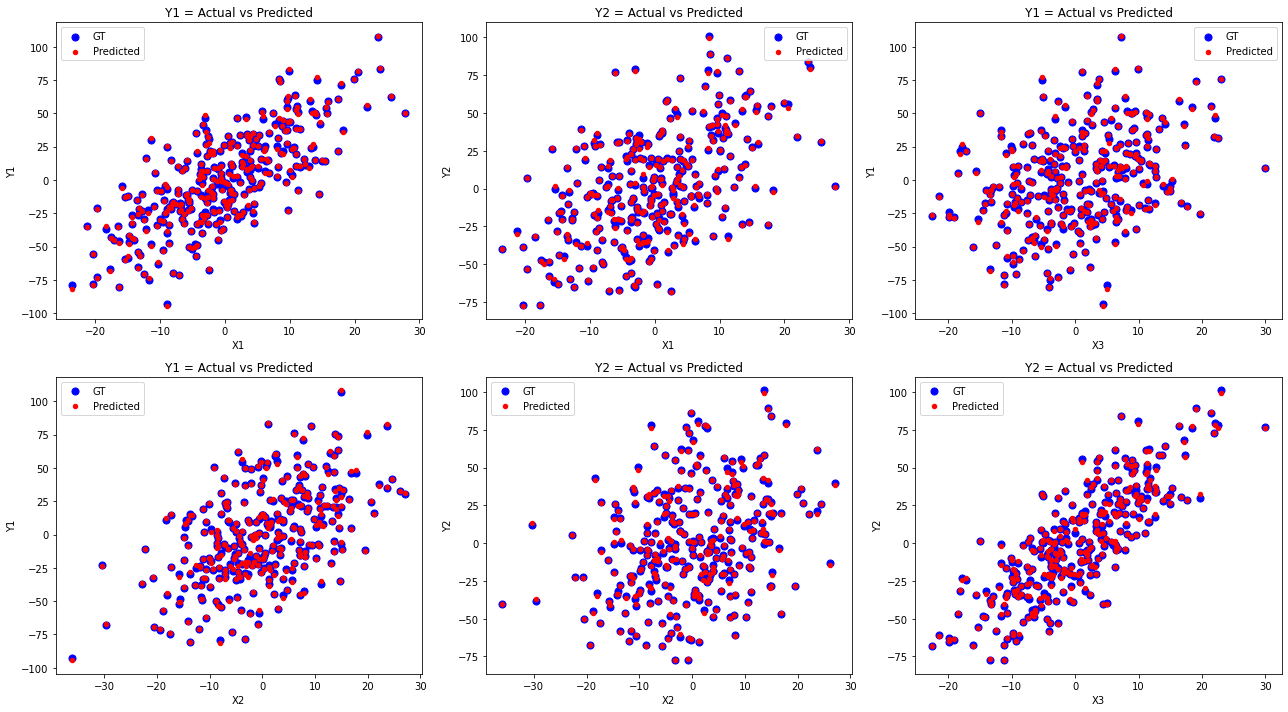

In [138]:
plt.figure(figsize=(18, 10))

# Plotting Y1 Actual vs Predicted
plt.subplot(2, 3, 1)
plt.scatter(X_test['X1'], Y_test['y1'], color = 'blue', s=50, label='GT')
plt.scatter(X_test['X1'], Y_pred[:, 0], color = 'red', s=20, label='Predicted')
plt.title('Y1 = Actual vs Predicted')
plt.xlabel('X1')
plt.ylabel('Y1')
plt.legend()

# Plotting Y2 Actual vs Predicted
plt.subplot(2, 3, 2)
plt.scatter(X_test['X1'], Y_test['y2'], color = 'blue', s=50, label='GT')
plt.scatter(X_test['X1'], Y_pred[:, 1], color = 'red', s=20, label='Predicted')
plt.title('Y2 = Actual vs Predicted')
plt.xlabel('X1')
plt.ylabel('Y2')
plt.legend()

# Plotting Y1 Actual vs Predicted
plt.subplot(2, 3, 4)
plt.scatter(X_test['X2'], Y_test['y1'], color = 'blue', s=50, label='GT')
plt.scatter(X_test['X2'], Y_pred[:, 0], color = 'red', s=20, label='Predicted')
plt.title('Y1 = Actual vs Predicted')
plt.xlabel('X2')
plt.ylabel('Y1')
plt.legend()

# Plotting Y2 Actual vs Predicted
plt.subplot(2, 3, 5)
plt.scatter(X_test['X2'], Y_test['y2'], color = 'blue', s=50, label='GT')
plt.scatter(X_test['X2'], Y_pred[:, 1], color = 'red', s=20, label='Predicted')
plt.title('Y2 = Actual vs Predicted')
plt.xlabel('X2')
plt.ylabel('Y2')
plt.legend()

# Plotting Y1 Actual vs Predicted
plt.subplot(2, 3, 3)
plt.scatter(X_test['X3'], Y_test['y1'], color = 'blue', s=50, label='GT')
plt.scatter(X_test['X3'], Y_pred[:, 0], color = 'red', s=20, label='Predicted')
plt.title('Y1 = Actual vs Predicted')
plt.xlabel('X3')
plt.ylabel('Y1')
plt.legend()

# Plotting Y2 Actual vs Predicted
plt.subplot(2, 3, 6)
plt.scatter(X_test['X3'], Y_test['y2'], color = 'blue', s=50, label='GT')
plt.scatter(X_test['X3'], Y_pred[:, 1], color = 'red', s=20, label='Predicted')
plt.title('Y2 = Actual vs Predicted')
plt.xlabel('X3')
plt.ylabel('Y2')
plt.legend()

plt.tight_layout()
plt.show()

마찬가지로 세 가지 변수에 대해 매우 정확하게 테스트 데이터를 예측하는 것을 확인할 수 있습니다. 

---
### 3.5 모델 평가 지표

In [295]:
print('Mean Absolute Error:', metrics.mean_absolute_error(Y_test, Y_pred))  
print('Mean Squared Error:', metrics.mean_squared_error(Y_test, Y_pred))  
print('Root Mean Squared Error:', np.sqrt(metrics.mean_squared_error(Y_test, Y_pred)))
print('R2 Score:', metrics.r2_score(Y_test, Y_pred))

Mean Absolute Error: 0.7629727781494475
Mean Squared Error: 0.9046590051478881
Root Mean Squared Error: 0.9511356397212167
R2 Score: 0.9992733047231868


---
## 4. 피처 엔지니어링의 중요성
---
### 4.1 중요한 피처가 누락된 경우
피처 엔지니어링의 중요성을 파악하기 위해 두 가지 상황을 가정해보겠습니다. 

우선, 위에서 수행한 다중 회귀 문제에서 중요한 피처를 일부로 누락시켜보겠습니다.

In [296]:
X = df[['X1', 'X2']]
y = df[['y1', 'y2']]
X_train, X_test, Y_train, Y_test = train_test_split(X, y, test_size=0.3, random_state=random_seed)

print(X_train.shape)
print(X_test.shape)
print(Y_train.shape)
print(Y_test.shape)

(700, 2)
(300, 2)
(700, 2)
(300, 2)


X3 변수를 입력 변수에서 제거했습니다. 나머지 과정을 동일하게 진행해보겠습니다.

In [297]:
# 회귀 모델을 생성하고 학습합니다
model = LinearRegression()
model.fit(X_train, Y_train)

# 학습한 모델을 이용해 테스트 데이터에 대해 예측을 합니다
Y_pred = model.predict(X_test)

In [298]:
# 예측한 각 변수의 계수를 확인합니다.
print("예측 식: y1 = {:.3f} X1 + {:.3f} X2 + {:.3f} X3 ".format(model.coef_[0][0], model.coef_[0][1], 0.))
print("실제 식: y1 = {:.3f} X1 + {:.3f} X2 + {:.3f} X3 ".format(beta_11, beta_12, beta_13))
print()
print("예측 식: y2 = {:.3f} X1 + {:.3f} X2 + {:.3f} X3 ".format(model.coef_[1][0], model.coef_[1][1], 0.))
print("실제 식: y2 = {:.3f} X1 + {:.3f} X2 + {:.3f} X3 ".format(beta_21, beta_22, beta_23))

예측 식: y1 = 2.989 X1 + 2.003 X2 + 0.000 X3 
실제 식: y1 = 3.000 X1 + 2.000 X2 + 1.000 X3 

예측 식: y2 = 1.959 X1 + 1.018 X2 + 0.000 X3 
실제 식: y2 = 2.000 X1 + 1.000 X2 + 3.000 X3 


In [299]:
print('Mean Absolute Error:', metrics.mean_absolute_error(Y_test, Y_pred))  
print('Mean Squared Error:', metrics.mean_squared_error(Y_test, Y_pred))  
print('Root Mean Squared Error:', np.sqrt(metrics.mean_squared_error(Y_test, Y_pred)))
print('R2 Score:', metrics.r2_score(Y_test, Y_pred))

Mean Absolute Error: 14.797598206004075
Mean Squared Error: 418.66178675797823
Root Mean Squared Error: 20.461226423603698
R2 Score: 0.6676212917672819


기존의 결과는 아래와 같습니다: 

- Mean Absolute Error: 0.7629727781494475
- Mean Squared Error: 0.9046590051478881
- Root Mean Squared Error: 0.9511356397212167
- R2 Score: 0.9992733047231868

중요한 피처가 모두 포함된 후 학습된 모델에 비해, 예측 결과가 매우 좋지 않습니다.

따라서, 데이터셋에 중요한 피처가 모두 포함되도록 전문가들의 노력이 필요합니다.

도메인 지식이 결여된 상태에서 학습을 진행하면, 어떤 노력을 들여도 성능을 올릴 수 없습니다.

---
### 4.2 불필요한 피처가 추가된 경우
이번에는 오히려 불필요한 피처를 추가해보겠습니다.

이러할 경우, 인공지능 모델의 학습이 잘 이뤄진다면, 불필요한 데이터에 대해 가중치를 크게 떨어뜨리는 방향으로 학습이 진행되었을 겁니다.

이러한 영향을 확인해보겠습니다.

In [300]:
X4 = np.random.normal(size=data_size) * 10

df = pd.DataFrame({
    'X1': X1.flatten(),
    'X2': X2.flatten(),
    'X3': X3.flatten(),
    'X4': X4.flatten(),
    'y1': y1.flatten(),
    'y2': y2.flatten()
})

In [301]:
X = df[['X1', 'X2', 'X3', 'X4']]
y = df[['y1', 'y2']]
X_train, X_test, Y_train, Y_test = train_test_split(X, y, test_size=0.3, random_state=random_seed)

print(X_train.shape)
print(X_test.shape)
print(Y_train.shape)
print(Y_test.shape)

(700, 4)
(300, 4)
(700, 2)
(300, 2)


종속변수 y와는 관련없는 X4 변수를 입력으로 제공합니다.

In [302]:

# 회귀 모델을 생성하고 학습합니다
model = LinearRegression()
model.fit(X_train, Y_train)

# 학습한 모델을 이용해 테스트 데이터에 대해 예측을 합니다
Y_pred = model.predict(X_test)

In [303]:
# 예측한 각 변수의 계수를 확인합니다.
print("예측 식: y1 = {:.3f} X1 + {:.3f} X2 + {:.3f} X3 + {:.3f} X4".format(model.coef_[0][0], model.coef_[0][1], model.coef_[0][2],model.coef_[0][3]))
print("실제 식: y1 = {:.3f} X1 + {:.3f} X2 + {:.3f} X3 ".format(beta_11, beta_12, beta_13))
print()
print("예측 식: y2 = {:.3f} X1 + {:.3f} X2 + {:.3f} X3 + {:.3f} X4".format(model.coef_[1][0], model.coef_[1][1], model.coef_[1][2], model.coef_[1][3]))
print("실제 식: y2 = {:.3f} X1 + {:.3f} X2 + {:.3f} X3 ".format(beta_21, beta_22, beta_23))

예측 식: y1 = 3.004 X1 + 1.996 X2 + 0.998 X3 + 0.001 X4
실제 식: y1 = 3.000 X1 + 2.000 X2 + 1.000 X3 

예측 식: y2 = 2.004 X1 + 0.998 X2 + 3.003 X3 + 0.004 X4
실제 식: y2 = 2.000 X1 + 1.000 X2 + 3.000 X3 


In [304]:
print('Mean Absolute Error:', metrics.mean_absolute_error(Y_test, Y_pred))  
print('Mean Squared Error:', metrics.mean_squared_error(Y_test, Y_pred))  
print('Root Mean Squared Error:', np.sqrt(metrics.mean_squared_error(Y_test, Y_pred)))
print('R2 Score:', metrics.r2_score(Y_test, Y_pred))

Mean Absolute Error: 0.7643631028625251
Mean Squared Error: 0.9058344207388614
Root Mean Squared Error: 0.9517533402824817
R2 Score: 0.9992723693190619


기존의 결과는 아래와 같습니다: 

- Mean Absolute Error: 0.7629727781494475
- Mean Squared Error: 0.9046590051478881
- Root Mean Squared Error: 0.9511356397212167
- R2 Score: 0.9992733047231868

불필요한 피처가 포함되면 성능이 일부 떨어지는 것을 확인할 수 있습니다.

현재 예시에서는 X4를 정규분포에서 샘플링한 것이기 때문에 우연에 의한 규칙을 찾지 못해 예측 계수가 매우 작게 예측되었습니다.

하지만, 불필요한 피처에 학습 데이터 중 종속 변수와 우연한 패턴이 있다면, 큰 과적합을 일으킬 수도 있습니다.

---
## 5. 실습 데이터 불러오기 및 선형 회귀 모델 적용
선형 회귀 모델을 실습 데이터에 적용해보겠습니다.

---
### 5.1 실습 데이터 불러오기
이전 실습에서 모든 전처리가 끝난 실습데이터를 불러오겠습니다.

In [305]:
df = pd.read_csv('./data/processed.csv') # df: dataframe의 줄임말
df.drop(columns = df.columns[0], axis = 1, inplace= True) # 데이터 순서를 표현하는 첫 열을 제거합니다.
display(df)

,Spacegroup,Formation Energy (eV),E Above Hull (eV),Band Gap (eV),Nsites,Density (gm/cc),Has Bandstructure,Crystal System
0,-0.9460,0.96830,1.1120,-1.5800,0.74170,2.61300,-2.0500,0.03653
1,-0.9460,-1.51900,-0.8633,1.1600,-0.55500,-0.63300,-2.0500,0.03653
2,-0.8640,0.07587,-0.4023,0.9644,-0.55500,1.21500,0.4863,1.16200
3,-0.7820,0.15210,0.9810,-1.0090,0.74170,1.06500,0.4863,-1.08900
4,-0.9460,-0.09820,0.8490,-0.2323,0.09344,-1.55700,0.4863,0.03653
...,...,...,...,...,...,...,...,...
324,-0.1285,0.51100,-1.4560,0.5635,-0.29570,0.49440,0.4863,1.16200
325,1.5060,0.51660,-1.4230,0.6226,-0.29570,0.68360,0.4863,1.16200
326,-0.9460,0.50600,1.3430,-1.0150,-0.72800,0.13280,0.4863,0.03653
327,-0.8640,-0.26680,0.6846,0.5664,-0.55500,-0.11304,0.4863,1.16200


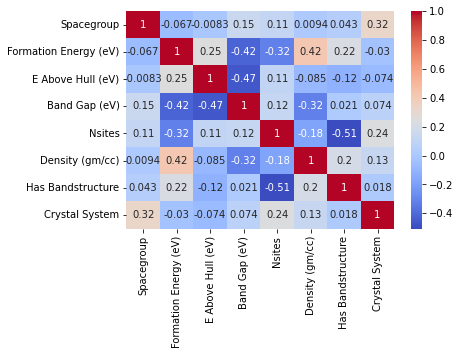

In [306]:
corr = df.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

---
### 5.2 학습 & 테스트 데이터 구분
7:3 의 비율로 학습 데이터와 테스트 데이터를 구분합니다.

이때 Crystal System 데이터를 정답 데이터로 분리합니다.

In [307]:
target_col = 'Crystal System'

y = df[target_col]
y = y.astype('category').cat.codes
X = df.drop(target_col, axis=1)
X_train, X_test, Y_train, Y_test = train_test_split(X, y, test_size=0.3, random_state=random_seed)

print(X_train.shape)
print(X_test.shape)
print(Y_train.shape)
print(Y_test.shape)

(230, 7)
(99, 7)
(230,)
(99,)


---
### 5.3 선형 회귀 모델 학습
sklearn 라이브러리를 이용해 선형 회귀 모델을 학습합니다. 학습 데이터만 사용해 학습을 진행합니다.

In [308]:
# 회귀 모델을 생성하고 학습합니다
model = LinearRegression()
model.fit(X_train, Y_train)


LinearRegression()

### 5.4 테스트 데이터 예측
학습한 모델을 이용해 테스트 데이터를 예측합니다. 

In [309]:
# 학습한 모델을 이용해 테스트 데이터에 대해 예측을 합니다
Y_pred = model.predict(X_test)

In [310]:
print('Mean Absolute Error:', metrics.mean_absolute_error(Y_test, Y_pred))  
print('Mean Squared Error:', metrics.mean_squared_error(Y_test, Y_pred))  
print('Root Mean Squared Error:', np.sqrt(metrics.mean_squared_error(Y_test, Y_pred)))
print('R2 Score:', metrics.r2_score(Y_test, Y_pred))

Mean Absolute Error: 0.7670686914069238
Mean Squared Error: 0.7065664520645919
Root Mean Squared Error: 0.840575072236021
R2 Score: 0.13544846483332518


선형 회귀 모델을 적용하여 Crystal System의 값을 예측해보았습니다. 

선형 회귀 모델을 적용할 때, Crystal System이 연속적인 값이라고 가정하고 학습 및 성능 지표를 적용해보았습니다.

---

## 6. 로지스틱 회귀 모델
---
### 6.1 로지스틱 회귀 모델 학습
실습데이터에서 Crystal System은 세 가지 결정 구조 중 하나를 나타내고 있습니다. 따라서 이는 불연속적인 범주형 데이터로 취급하는 것이 적합합니다.

회귀를 이용해 분류 문제를 풀 때, 가장 흔히 사용되는 로지스틱 회귀 모델을 적용해보겠습니다.

In [311]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# 다중 클래스 분류를 위한 로지스틱 회귀 모델
logistic_model = LogisticRegression(multi_class='multinomial', solver='lbfgs')
logistic_model.fit(X_train, Y_train)


LogisticRegression(multi_class='multinomial')

---
### 6.2 모델 평가 지표
분류 문제에서 가장 직관적으로 모델의 성능을 평가할 수 있는 방법은 정답률을 확인하는 것입니다.

정답률(Accuracy)는 정답 클래스를 맞췄는지 맞추지 못했는지에 대한 직관적인 수치를 제공합니다.

In [312]:
# Prediction
Y_pred_logistic = logistic_model.predict(X_test)

# Accuracy
accuracy_logistic = accuracy_score(Y_test, Y_pred_logistic)
print("Logistic Regression Accuracy: ", accuracy_logistic)

Logistic Regression Accuracy:  0.6666666666666666


로지스틱 모델이 66.6% 의 정답률을 갖는다는 것을 확인할 수 있습니다.

---
### 6.3 다양한 로지스틱 회귀 모델 적용해보기
로지스틱 회귀 모델에서 알고리즘을 계산하는 방법에는 여러가지가 있습니다. lbfgs 모델 외의 다른 방법들을 사용해 정답률을 확인해보겠습니다.

먼저 newton-cg 방법을 적용해보겠습니다.

In [313]:

logistic_model = LogisticRegression(multi_class='multinomial', solver='newton-cg')
logistic_model.fit(X_train, Y_train)

# Prediction
Y_pred_logistic = logistic_model.predict(X_test)

# Accuracy
accuracy_logistic = accuracy_score(Y_test, Y_pred_logistic)
print("Logistic Regression Accuracy: ", accuracy_logistic)

Logistic Regression Accuracy:  0.6666666666666666


다음은 sag 방법을 적용해보겠습니다.

In [314]:

logistic_model = LogisticRegression(multi_class='multinomial', solver='sag')
logistic_model.fit(X_train, Y_train)

# Prediction
Y_pred_logistic = logistic_model.predict(X_test)

# Accuracy
accuracy_logistic = accuracy_score(Y_test, Y_pred_logistic)
print("Logistic Regression Accuracy: ", accuracy_logistic)

Logistic Regression Accuracy:  0.6666666666666666


마지막으로 saga 방법을 적용해보겠습니다.

In [315]:

logistic_model = LogisticRegression(multi_class='multinomial', solver='saga')
logistic_model.fit(X_train, Y_train)

# Prediction
Y_pred_logistic = logistic_model.predict(X_test)

# Accuracy
accuracy_logistic = accuracy_score(Y_test, Y_pred_logistic)
print("Logistic Regression Accuracy: ", accuracy_logistic)

Logistic Regression Accuracy:  0.6666666666666666


모든 방법들이 66.6% 의 정답률을 갖는다는 것을 확인할 수 있습니다.

이를 통해 알 수 있는 사실은, 결정 구조와 독립 변수들 사이에는 단순한 선형적인 관계가 아닌, 복잡한 비선형적 관계를 갖는다는 것입니다.

따라서, 선형 회귀 모델을 이용해서는 높은 성능을 낼 수 없다는 것을 확인할 수 있습니다.